# Classement par le modèle Bradley-Terry 

Modèle de Bradley-Terry:
P(i bat j) = βᵢ / (βᵢ + βⱼ)
où βᵢ est le paramètre de « force créative » du modèle i, estimé par maximum de vraisemblance. Les ex-æquo (both_equal = True) peuvent être gérés par l’extension Davidson (1970).

## Préparation dataset

In [35]:
from pathlib import Path
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# This gets the directory where your notebook/script is located
base_dir = Path.cwd() 

# Build the path safely
file_path = base_dir.parent / "data" / "comparia-votes" / "votes_samples.jsonl"

# Read the file
df_votes = pd.read_json(file_path, lines=True)

In [36]:
df_votes.head()

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,conv_turns,selected_category,is_unedited_prompt,conversation_pair_id,session_hash,visitor_id,conv_comments_a,conv_comments_b,conv_useful_a,conv_useful_b,conv_creative_a,conv_creative_b,conv_clear_formatting_a,conv_clear_formatting_b,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,4400,2024-10-14 12:35:18.238,gemma-2-9b-it,phi-3.5-mini-instruct,"[gemma-2-9b-it, phi-3.5-mini-instruct]",gemma-2-9b-it,Comment rédiger une attestation d'hébergement ...,NaN,"[{'role': 'user', 'content': 'Comment rédiger ...","[{'role': 'user', 'content': 'Comment rédiger ...",1,administrative,True,cd6f1b6fe7914ab59e5714a340a6c75c-e0d4241d798e4...,eefjajqsjjj,c1fc1f428e2a654520736b34a33b1204,,,False,False,False,False,True,False,False,False,False,True,False,False,,,True,True
1,109754,2025-10-19 11:48:33.355,command-a,glm-4.6,"[command-a, glm-4.6]",NaN,Faites moi un script python pour jouer à Mario...,1.0,"[{'role': 'user', 'content': 'Faites moi un sc...","[{'role': 'user', 'content': 'Faites moi un sc...",1,NaN,False,e1edd24739824a8a883a63c29af1c360-c5551a40bfa64...,2ze917ia8cv,99c92d64850a82de6b79a1df195cfb21,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False
2,129388,2025-12-01 12:46:14.799,qwen3-max-2025-09-23,gpt-5-nano,"[gpt-5-nano, qwen3-max-2025-09-23]",NaN,QUEL EST VOTRE IMPACT SUR LENVIRONEMENT,1.0,"[{'role': 'user', 'content': 'QUEL EST VOTRE I...","[{'role': 'user', 'content': 'QUEL EST VOTRE I...",1,NaN,False,87392847c2844ac0bc592a2091685cf6-bcb25a54f6d04...,zd20d86o0nn,98fe43ad844a15d7f00af754e45ed81e,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False
3,144518,2026-01-09 09:48:49.521,deepseek-r1-0528,glm-4.7,"[deepseek-r1-0528, glm-4.7]",NaN,connais tu Malone Courtecuisse,1.0,"[{'role': 'user', 'content': 'connais tu Malon...","[{'role': 'user', 'content': 'connais tu Malon...",1,NaN,False,599de720bd804301b141a39fb9ee9b11-0cf07a983f754...,14fv0eqe917d,fc56866e083476414e83d6f9e3c7f278,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False
4,171722,2026-03-10 13:59:52.684,gemini-3.1-flash-lite-preview,EuroLLM-22B-Instruct-2512,"[EuroLLM-22B-Instruct-2512, gemini-3.1-flash-l...",EuroLLM-22B-Instruct-2512,quel sera le prochain président de la républiq...,0.0,"[{'role': 'user', 'content': 'quel sera le pro...","[{'role': 'user', 'content': 'quel sera le pro...",1,NaN,False,47be83af3bab4ab28f134368f708ec59-0f9b513ce1da4...,34162365-e7f7-4e0b-bcb4-68b35e79ac1d,2d2b8037ac25d1b5b77090ccdd92e1c9,,,False,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,False


In [37]:
df_votes.columns

Index(['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name',
       'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a',
       'conversation_b', 'conv_turns', 'selected_category',
       'is_unedited_prompt', 'conversation_pair_id', 'session_hash',
       'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a',
       'conv_useful_b', 'conv_creative_a', 'conv_creative_b',
       'conv_clear_formatting_a', 'conv_clear_formatting_b',
       'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a',
       'conv_superficial_b', 'conv_instructions_not_followed_a',
       'conv_instructions_not_followed_b', 'system_prompt_b',
       'system_prompt_a', 'conv_complete_a', 'conv_complete_b'],
      dtype='str')

In [38]:
df_votes.isnull().sum()

id                                    0
timestamp                             0
model_a_name                          0
model_b_name                          0
model_pair_name                       0
chosen_model_name                   344
opening_msg                           0
both_equal                           81
conversation_a                        0
conversation_b                        0
conv_turns                            0
selected_category                   935
is_unedited_prompt                    0
conversation_pair_id                  0
session_hash                          0
visitor_id                            0
conv_comments_a                       0
conv_comments_b                       0
conv_useful_a                         0
conv_useful_b                         0
conv_creative_a                       0
conv_creative_b                       0
conv_clear_formatting_a               0
conv_clear_formatting_b               0
conv_incorrect_a                      0


In [39]:
df_votes.shape

(1000, 34)

In [40]:
df_votes["selected_category"].value_counts()

selected_category
ideas              16
explanations       12
iasummit            8
stories             7
recipes             7
coach               5
administrative      4
recommendations     4
unguided            1
expression          1
Name: count, dtype: int64

les colones qui nous intéressent sont :
- model_a_name : le nom du modèle A
- model_b_name : le nom du modèle B
- chosen_model_name : le modèle choisi par le juge
- both_equal : indique si les deux modèles sont jugés égaux
- conv_creative_a: la conversation associée au modèle A est elle créative ou non
- conv_creative_b: la conversation associée au modèle B est elle créative ou non

In [41]:
df_votes_good_columns = df_votes[["model_a_name", "model_b_name", "chosen_model_name", "both_equal", "conv_creative_a", "conv_creative_b"]]
df_votes_good_columns.head()

,model_a_name,model_b_name,chosen_model_name,both_equal,conv_creative_a,conv_creative_b
0,gemma-2-9b-it,phi-3.5-mini-instruct,gemma-2-9b-it,NaN,False,False
1,command-a,glm-4.6,NaN,1.0,False,False
2,qwen3-max-2025-09-23,gpt-5-nano,NaN,1.0,False,False
3,deepseek-r1-0528,glm-4.7,NaN,1.0,False,False
4,gemini-3.1-flash-lite-preview,EuroLLM-22B-Instruct-2512,EuroLLM-22B-Instruct-2512,0.0,False,False


Maintenant netoyons les données pour ne garder que les colonnes qui nous intéressent et vérifier qu’il n’y a pas de valeurs manquantes.

In [42]:
df_votes_good_columns.isnull().sum()

model_a_name           0
model_b_name           0
chosen_model_name    344
both_equal            81
conv_creative_a        0
conv_creative_b        0
dtype: int64

On voit que l'on a des valeurs manquantes dans les colones chosen_model_name et both_eaqual, regardons si both_equal est null lorsque chosen_model_name n'est pas null et vice versa pour comprendre la nature de ces valeurs manquantes.

In [43]:
# vérifier si il ya des lignes où both equal est null et chosen_model_name est null
df_votes_good_columns[(df_votes_good_columns["both_equal"].isnull()) & (df_votes_good_columns["chosen_model_name"].isnull())]

,model_a_name,model_b_name,chosen_model_name,both_equal,conv_creative_a,conv_creative_b
33,llama-3.1-70b,mixtral-8x7b-instruct-v0.1,NaN,NaN,True,True
70,llama-3.1-70b,llama-3.1-8b,NaN,NaN,False,False
133,gemini-1.5-pro,gemma-2-9b-it,NaN,NaN,False,False
134,llama-3.1-405b,lfm-40b,NaN,NaN,False,False
218,qwen2.5-7b-instruct,llama-3.1-405b,NaN,NaN,False,False
257,phi-3.5-mini-instruct,mixtral-8x7b-instruct-v0.1,NaN,NaN,False,False
307,gemma-2-9b-it,llama-3.1-405b,NaN,NaN,False,False
385,phi-3.5-mini-instruct,llama-3.1-405b,NaN,NaN,False,False
435,gpt-4o-2024-08-06,ministral-8b-instruct-2410,NaN,NaN,False,False
459,llama-3.1-8b,gpt-4o-mini-2024-07-18,NaN,NaN,False,False


In [44]:
df_votes_good_columns[(df_votes_good_columns["both_equal"].isnull()) & (df_votes_good_columns["chosen_model_name"].isnull())].shape

(21, 6)

On a 21 lignes où both_equal est null et chosen_model_name est null, il s'agit probablement de lignes où le juge n'a rien dit sur ses préférences donc on va supprimer ces lignes.

In [45]:

df_votes_good_columns_first_clean = df_votes_good_columns.dropna(subset=["both_equal", "chosen_model_name"], how="all")

In [46]:
df_votes_good_columns_first_clean.isnull().sum()

model_a_name           0
model_b_name           0
chosen_model_name    323
both_equal            60
conv_creative_a        0
conv_creative_b        0
dtype: int64

In [47]:
df_votes_good_columns_first_clean["both_equal"].value_counts()

both_equal
0.0    596
1.0    323
Name: count, dtype: int64

regardons les vaeleurs de chosen_model_name quand both_equal est null pour voir si il ya des anomalies.

In [48]:
df_votes_good_columns_first_clean[df_votes_good_columns_first_clean["both_equal"].isnull()]["chosen_model_name"].value_counts(dropna=False)

chosen_model_name
gemini-1.5-pro                12
llama-3.1-405b                 9
phi-3.5-mini-instruct          8
llama-3.1-70b                  6
ministral-8b-instruct-2410     4
gemma-2-27b-it-q8              4
gemma-2-9b-it                  3
mistral-nemo-2407              3
qwen2.5-7b-instruct            3
mixtral-8x7b-instruct-v0.1     2
lfm-40b                        2
qwen2-7b-instruct              1
hermes-3-llama-3.1-405b        1
gpt-4o-2024-08-06              1
c4ai-command-r-08-2024         1
Name: count, dtype: int64

OK donc à chaque fois que both_equal est null, chosen_model_name a une valeur donc on peut remplacer les valeurs manquantes de both_equal par False.

In [49]:
df_votes_good_columns_second_clean=df_votes_good_columns_first_clean.copy()
df_votes_good_columns_second_clean["both_equal"] = df_votes_good_columns_second_clean["both_equal"].fillna(False)
df_votes_good_columns_second_clean.isnull().sum()

model_a_name           0
model_b_name           0
chosen_model_name    323
both_equal             0
conv_creative_a        0
conv_creative_b        0
dtype: int64

Ok maintenant je voudrais voir les valeurs de chosen_model_name quand both_equal est True pour voir si il ya des anomalies.

In [50]:
df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == True]["chosen_model_name"].value_counts(dropna=False)

chosen_model_name
NaN    323
Name: count, dtype: int64

On voit que l'on a que des nan donc le dataset est bien nettoyé de ce côté, maintenant il ne reste plus qu'à regarder les valeurs de chosen_model_name quand both_equal est False pour voir si il ya des anomalies.

In [51]:
df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == False]["chosen_model_name"].value_counts(dropna=False)

chosen_model_name
gemma-3-4b                         33
gemini-2.0-flash                   24
gemini-1.5-pro                     22
ministral-8b-instruct-2410         20
command-a                          18
gemma-3-12b                        17
mistral-medium-2508                15
llama-3.3-70b                      15
llama-3.1-405b                     15
deepseek-v3-0324                   15
llama-3.1-nemotron-70b-instruct    14
mistral-large-2411                 14
llama-3.1-8b                       14
mistral-small-3.1-24b              13
phi-4                              13
llama-4-scout                      13
claude-3-5-sonnet-v2               12
gpt-4.1-mini                       12
gemma-3n-e4b-it                    11
gemini-2.5-flash                   11
o4-mini                            10
claude-4-5-sonnet                  10
gemma-3-27b                        10
llama-3.1-70b                       9
hermes-3-llama-3.1-405b             9
mistral-small-2506              

In [52]:
df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == False]["chosen_model_name"].nunique()

85

OK on voit que l'on a bien des noms de modèles à chaque fois donc pas des strings vides etc.. Donc le dataset est propre de ce côté là aussi. Maintenant vérifions que à chaque fois que chosen_model_name n'est pas null, le chosen_model_name correspond bien à l'un des deux modèles en compétition (model_a_name ou model_b_name).

In [53]:
total_good_rows = df_votes_good_columns_second_clean.shape[0]
for index, row in df_votes_good_columns_second_clean.iterrows():
    if pd.notnull(row["chosen_model_name"]):
        if row["chosen_model_name"] != row["model_a_name"] and row["chosen_model_name"] != row["model_b_name"]:
            print(f"Anomaly found at index {index}: chosen_model_name is {row['chosen_model_name']} but model_a_name is {row['model_a_name']} and model_b_name is {row['model_b_name']}")
            total_good_rows -= 1
print(f"Total good rows: {total_good_rows} out of {df_votes_good_columns_second_clean.shape[0]}")

Total good rows: 979 out of 979


OK maintenant on a tout qui est bon maintenant on peut faire notre analyse de Bradley-Terry.

In [58]:
# récupérer tous les modèles testés
models_tested = set(df_votes_good_columns_second_clean["model_a_name"].unique()).union(set(df_votes_good_columns_second_clean["model_b_name"].unique()))
print(len(models_tested))

98


In [60]:
#combien de fois chaque modèle a était testé
model_test_counts = {}
for model in models_tested:
    count_a = df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["model_a_name"] == model].shape[0]
    count_b = df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["model_b_name"] == model].shape[0]
    model_test_counts[model] = count_a + count_b
#sort the models by the number of tests
model_test_counts = dict(sorted(model_test_counts.items(), key=lambda item: item[1], reverse=True))
print(model_test_counts)

{'gemma-3-4b': 68, 'llama-3.1-8b': 58, 'gemini-2.0-flash': 53, 'phi-4': 51, 'ministral-8b-instruct-2410': 51, 'qwen2.5-coder-32b-instruct': 47, 'llama-3.1-405b': 47, 'llama-3.3-70b': 46, 'gemma-3-12b': 45, 'gemini-1.5-pro': 44, 'command-a': 42, 'gemma-3-27b': 41, 'mistral-small-2506': 40, 'gpt-4.1-mini': 37, 'mistral-medium-2508': 36, 'llama-3.1-nemotron-70b-instruct': 35, 'mistral-large-2411': 34, 'aya-expanse-32b': 33, 'llama-4-scout': 32, 'claude-3-5-sonnet-v2': 30, 'mistral-small-3.1-24b': 30, 'c4ai-command-r-08-2024': 29, 'deepseek-v3-0324': 29, 'claude-4-5-sonnet': 27, 'gemma-3n-e4b-it': 27, 'hermes-3-llama-3.1-405b': 27, 'gpt-4o-2024-08-06': 26, 'mistral-nemo-2407': 26, 'gpt-4.1-nano': 25, 'mistral-large-2512': 25, 'llama-3.1-70b': 24, 'gpt-4o-mini-2024-07-18': 24, 'qwen3-30b-a3b': 23, 'deepseek-r1': 23, 'mistral-saba': 22, 'gpt-5': 22, 'qwen-3-8b': 22, 'gpt-5-mini': 22, 'gemini-2.5-flash': 22, 'gpt-5-nano': 21, 'gemma-2-9b-it': 21, 'gpt-5.2': 19, 'gpt-5.1': 19, 'gemini-3-pro-pr

Ok il faudra supprimer des modèle du classement car ils n'ont été testé que très peu de fois et donc on n'a pas assez de données pour les départager. 

In [ ]:
df_whithout_equal = df_votes_good_columns_second_clean[df_votes_good_columns_second_clean["both_equal"] == False]


## Construction de la matrice de comparaisons

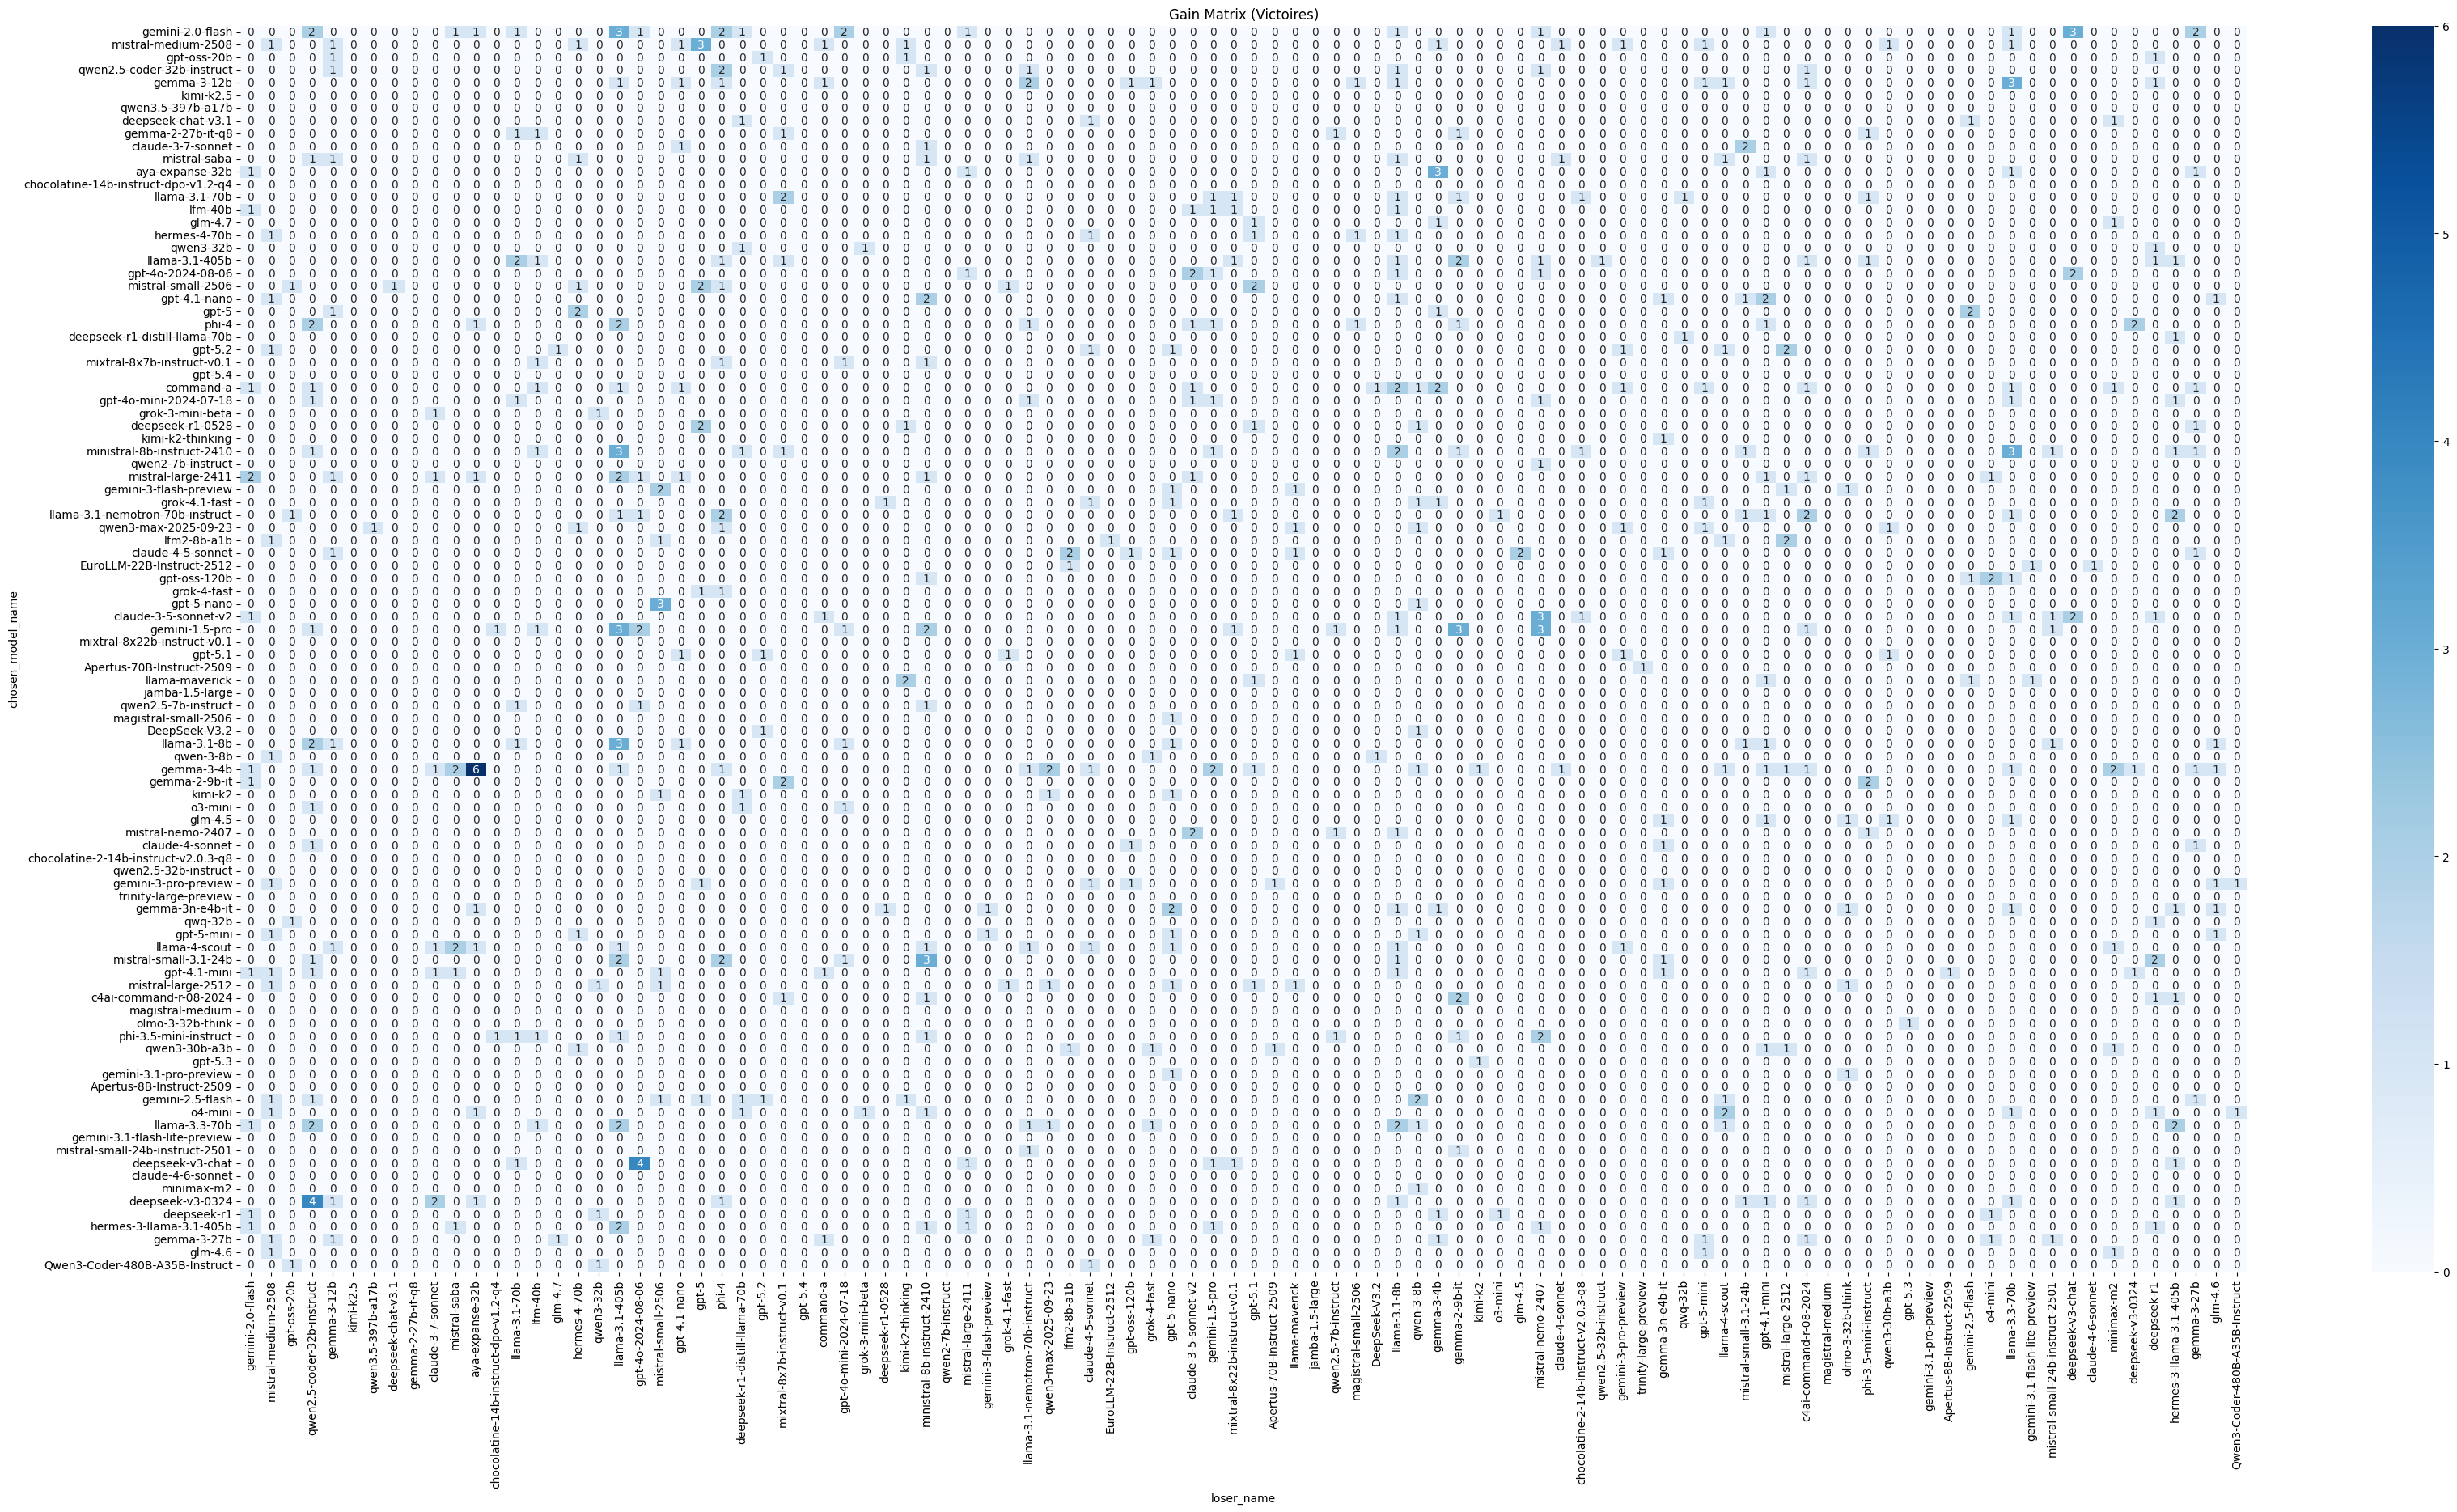

In [67]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df_whithout_equal.copy()

df['loser_name'] = np.where(
    df['chosen_model_name'] == df['model_a_name'], df['model_b_name'],
    np.where(df['chosen_model_name'] == df['model_b_name'], df['model_a_name'], None)
)

df_wins = df.dropna(subset=['loser_name', 'chosen_model_name'])

gain_matrix_fast = pd.crosstab(df_wins['chosen_model_name'], df_wins['loser_name'])

gain_matrix_fast = gain_matrix_fast.reindex(
    index=models_tested, 
    columns=models_tested, 
    fill_value=0
)

# Affichage
plt.figure(figsize=(40, 20))
sns.heatmap(gain_matrix_fast, annot=True, fmt="d", cmap="Blues")
plt.title("Gain Matrix (Victoires)")
plt.show()

In [68]:
# faire dictionnaire entre modèles et nombre de confrontations avec des sommes sur la gain matrix
model_confrontations = {}
for model in models_tested:
    wins = gain_matrix_fast.loc[model].sum()
    losses = gain_matrix_fast[model].sum()
    model_confrontations[model] = wins + losses

#sort the models by the number of confrontations
model_confrontations = dict(sorted(model_confrontations.items(), key=lambda item: item[1], reverse=True))
print(model_confrontations)


{'gemma-3-4b': np.int64(45), 'llama-3.1-405b': np.int64(43), 'ministral-8b-instruct-2410': np.int64(39), 'llama-3.1-8b': np.int64(38), 'gemini-2.0-flash': np.int64(36), 'llama-3.3-70b': np.int64(34), 'qwen2.5-coder-32b-instruct': np.int64(32), 'gemini-1.5-pro': np.int64(32), 'mistral-medium-2508': np.int64(29), 'phi-4': np.int64(29), 'gemma-3-12b': np.int64(28), 'gpt-4.1-mini': np.int64(25), 'llama-3.1-nemotron-70b-instruct': np.int64(24), 'command-a': np.int64(23), 'llama-4-scout': np.int64(22), 'aya-expanse-32b': np.int64(21), 'claude-3-5-sonnet-v2': np.int64(21), 'hermes-3-llama-3.1-405b': np.int64(21), 'mistral-large-2411': np.int64(20), 'mistral-nemo-2407': np.int64(20), 'mistral-small-3.1-24b': np.int64(20), 'gemma-3-27b': np.int64(20), 'mistral-small-2506': np.int64(19), 'gemma-3n-e4b-it': np.int64(19), 'c4ai-command-r-08-2024': np.int64(19), 'deepseek-v3-0324': np.int64(19), 'llama-3.1-70b': np.int64(18), 'gpt-4o-2024-08-06': np.int64(18), 'claude-4-5-sonnet': np.int64(18), 'ge

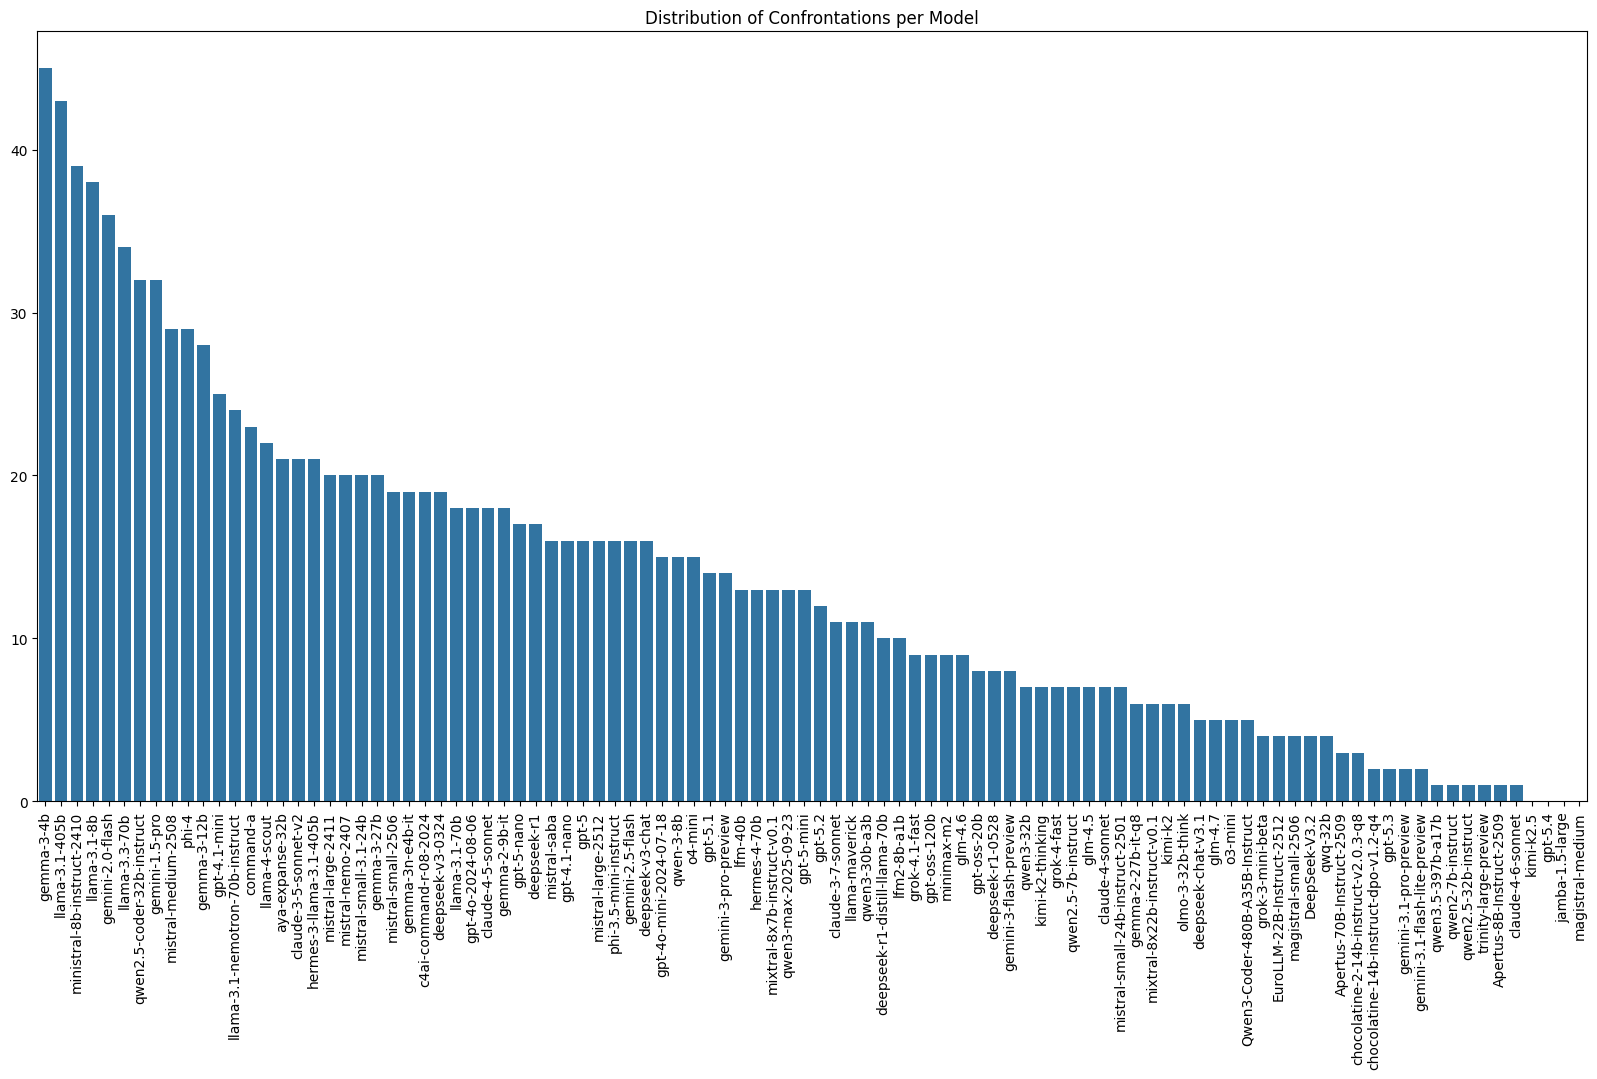

In [69]:
#plot the distribution of confrontations
plt.figure(figsize=(20, 10))
sns.barplot(x=list(model_confrontations.keys()), y=list(model_confrontations.values()))
plt.xticks(rotation=90)
plt.title("Distribution of Confrontations per Model")
plt.show()

In [70]:
print(len(model_confrontations))

98


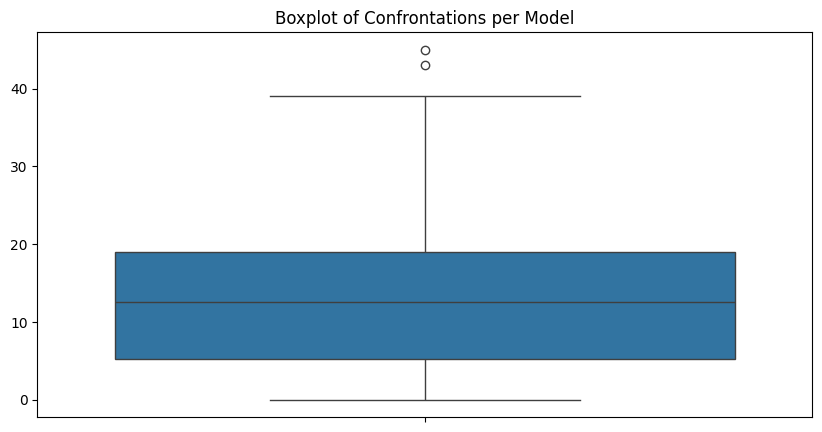

In [71]:
#boxplot of the distribution of confrontations
plt.figure(figsize=(10, 5))
sns.boxplot(y=list(model_confrontations.values()))
plt.title("Boxplot of Confrontations per Model")
plt.show()

Comme on ne peut pas bien estimer les modèles qui ont peu de confrontattions on va supprimer les modèles avec un nombre de confrontations inférieur au percentile 25 des confrontations.

In [72]:
#déterminer le percentile 25 des confrontations
confrontations_values = list(model_confrontations.values())
percentile_25 = np.percentile(confrontations_values, 25)
percentile_25

np.float64(5.25)

In [73]:
#combien de modèles ont un nombre de confrontations inférieur au percentile 25
models_below_percentile_25 = [model for model, confrontations in model_confrontations.items() if confrontations < percentile_25]
print(models_below_percentile_25)

['deepseek-chat-v3.1', 'glm-4.7', 'o3-mini', 'Qwen3-Coder-480B-A35B-Instruct', 'grok-3-mini-beta', 'EuroLLM-22B-Instruct-2512', 'magistral-small-2506', 'DeepSeek-V3.2', 'qwq-32b', 'Apertus-70B-Instruct-2509', 'chocolatine-2-14b-instruct-v2.0.3-q8', 'chocolatine-14b-instruct-dpo-v1.2-q4', 'gpt-5.3', 'gemini-3.1-pro-preview', 'gemini-3.1-flash-lite-preview', 'qwen3.5-397b-a17b', 'qwen2-7b-instruct', 'qwen2.5-32b-instruct', 'trinity-large-preview', 'Apertus-8B-Instruct-2509', 'claude-4-6-sonnet', 'kimi-k2.5', 'gpt-5.4', 'jamba-1.5-large', 'magistral-medium']


In [74]:
print(len(models_below_percentile_25))

25


 supprimons les modèles avec moins de 5.25 confrontations. et faisons le classement de Bradley-Terry avec les modèles restants.

In [75]:
# Supprimer les modèles avec moins de confrontations que le percentile 25
models_above_percentile_25 = [model for model, confrontations in model_confrontations.items() if confrontations >= percentile_25]
print(f"Nombre de modèles restants: {len(models_above_percentile_25)}")
print(f"Modèles supprimés: {len(models_below_percentile_25)}")

# Filtrer le dataframe pour ne garder que les confrontations entre modèles retenus
df_filtered = df_whithout_equal[
    (df_whithout_equal["model_a_name"].isin(models_above_percentile_25)) &
    (df_whithout_equal["model_b_name"].isin(models_above_percentile_25))
].copy()

print(f"Nombre de confrontations restantes: {df_filtered.shape[0]}")

Nombre de modèles restants: 73
Modèles supprimés: 25
Nombre de confrontations restantes: 599


In [76]:
# Reconstruire la gain matrix avec les modèles filtrés
df_filtered['loser_name'] = np.where(
    df_filtered['chosen_model_name'] == df_filtered['model_a_name'], df_filtered['model_b_name'],
    np.where(df_filtered['chosen_model_name'] == df_filtered['model_b_name'], df_filtered['model_a_name'], None)
)

df_filtered_wins = df_filtered.dropna(subset=['loser_name', 'chosen_model_name'])

gain_matrix_filtered = pd.crosstab(df_filtered_wins['chosen_model_name'], df_filtered_wins['loser_name'])
gain_matrix_filtered = gain_matrix_filtered.reindex(
    index=models_above_percentile_25, 
    columns=models_above_percentile_25, 
    fill_value=0
)

print(f"Taille de la gain matrix: {gain_matrix_filtered.shape}")
gain_matrix_filtered.head()

Taille de la gain matrix: (73, 73)


loser_name,gemma-3-4b,llama-3.1-405b,ministral-8b-instruct-2410,llama-3.1-8b,gemini-2.0-flash,llama-3.3-70b,qwen2.5-coder-32b-instruct,gemini-1.5-pro,mistral-medium-2508,phi-4,gemma-3-12b,gpt-4.1-mini,llama-3.1-nemotron-70b-instruct,command-a,llama-4-scout,aya-expanse-32b,claude-3-5-sonnet-v2,hermes-3-llama-3.1-405b,mistral-large-2411,mistral-nemo-2407,mistral-small-3.1-24b,gemma-3-27b,mistral-small-2506,gemma-3n-e4b-it,c4ai-command-r-08-2024,deepseek-v3-0324,llama-3.1-70b,gpt-4o-2024-08-06,claude-4-5-sonnet,gemma-2-9b-it,gpt-5-nano,deepseek-r1,mistral-saba,gpt-4.1-nano,gpt-5,mistral-large-2512,phi-3.5-mini-instruct,gemini-2.5-flash,deepseek-v3-chat,gpt-4o-mini-2024-07-18,qwen-3-8b,o4-mini,gpt-5.1,gemini-3-pro-preview,lfm-40b,hermes-4-70b,mixtral-8x7b-instruct-v0.1,qwen3-max-2025-09-23,gpt-5-mini,gpt-5.2,claude-3-7-sonnet,llama-maverick,qwen3-30b-a3b,deepseek-r1-distill-llama-70b,lfm2-8b-a1b,grok-4.1-fast,gpt-oss-120b,minimax-m2,glm-4.6,gpt-oss-20b,deepseek-r1-0528,gemini-3-flash-preview,qwen3-32b,kimi-k2-thinking,grok-4-fast,qwen2.5-7b-instruct,glm-4.5,claude-4-sonnet,mistral-small-24b-instruct-2501,gemma-2-27b-it-q8,mixtral-8x22b-instruct-v0.1,kimi-k2,olmo-3-32b-think
chosen_model_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
gemma-3-4b,0,1,0,0,1,1,1,2,0,1,0,1,1,0,1,6,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,2,0,0,1,0,0,0,0,1,0,1,0,0,0,0,2,0,0,1,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
llama-3.1-405b,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,2,0,0,2,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
ministral-8b-instruct-2410,0,3,0,2,0,3,1,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
llama-3.1-8b,0,3,0,0,0,0,2,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
gemini-2.0-flash,0,3,0,1,0,1,2,0,0,2,0,1,0,0,0,1,0,0,1,1,0,2,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 9.	Classement global : basé sur tous les votes de comparia-votes (chosen_model_name, both_equal).

### Implémentation du modèle de Bradley-Terry

On va estimer les paramètres $\beta_i$ par maximum de vraisemblance via l'algorithme itératif de Zermelo (MM algorithm) :

$$\beta_i^{(t+1)} = \frac{w_i}{\sum_{j \neq i} \frac{n_{ij}}{\beta_i^{(t)} + \beta_j^{(t)}}}$$

où :
- $w_i$ est le nombre total de victoires du modèle $i$
- $n_{ij}$ est le nombre total de confrontations entre $i$ et $j$

In [77]:
def bradley_terry_mle(gain_matrix, max_iter=1000, tol=1e-8):
    """
    Estime les paramètres du modèle de Bradley-Terry par l'algorithme MM (Zermelo).
    
    Parameters
    ----------
    gain_matrix : pd.DataFrame
        Matrice carrée W où W[i,j] = nombre de victoires de i contre j
    max_iter : int
        Nombre maximum d'itérations
    tol : float
        Seuil de convergence
    
    Returns
    -------
    beta : pd.Series
        Paramètres de force estimés (normalisés pour sommer à 1)
    log_likelihoods : list
        Log-vraisemblance à chaque itération
    """
    models = gain_matrix.index.tolist()
    n = len(models)
    W = gain_matrix.values.astype(float)
    
    # Nombre total de confrontations entre i et j
    N = W + W.T
    
    # Nombre total de victoires par modèle
    wins = W.sum(axis=1)
    
    # Initialisation uniforme
    beta = np.ones(n) / n
    
    log_likelihoods = []
    
    for iteration in range(max_iter):
        beta_old = beta.copy()
        
        # Calcul de la log-vraisemblance
        ll = 0
        for i in range(n):
            for j in range(i+1, n):
                if N[i, j] > 0:
                    ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
                    ll -= N[i, j] * np.log(beta[i] + beta[j])
        log_likelihoods.append(ll)
        
        # Mise à jour MM (Zermelo)
        for i in range(n):
            denom = 0
            for j in range(n):
                if i != j and N[i, j] > 0:
                    denom += N[i, j] / (beta[i] + beta[j])
            if denom > 0:
                beta[i] = wins[i] / denom
        
        # Normalisation pour que la somme = 1
        beta = beta / beta.sum()
        
        # Vérification de convergence
        if np.max(np.abs(beta - beta_old)) < tol:
            print(f"Convergence atteinte après {iteration + 1} itérations")
            break
    else:
        print(f"Pas de convergence après {max_iter} itérations")
    
    beta_series = pd.Series(beta, index=models)
    return beta_series, log_likelihoods

In [78]:
beta, log_likelihoods = bradley_terry_mle(gain_matrix_filtered)

# Classement des modèles par force
ranking = beta.sort_values(ascending=False)
print("\n=== Classement Bradley-Terry (paramètre β) ===")
for i, (model, score) in enumerate(ranking.items(), 1):
    print(f"{i:3d}. {model:40s} β = {score:.6f}")

C:\Users\rapha\AppData\Local\Temp\ipykernel_33104\3980210465.py:44: RuntimeWarning: divide by zero encountered in log
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
C:\Users\rapha\AppData\Local\Temp\ipykernel_33104\3980210465.py:44: RuntimeWarning: invalid value encountered in scalar multiply
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])


Pas de convergence après 1000 itérations

=== Classement Bradley-Terry (paramètre β) ===
  1. gemma-2-27b-it-q8                        β = 0.548856
  2. kimi-k2                                  β = 0.023836
  3. gpt-5.2                                  β = 0.021122
  4. gemma-3-4b                               β = 0.017733
  5. lfm2-8b-a1b                              β = 0.017070
  6. glm-4.5                                  β = 0.017054
  7. claude-4-5-sonnet                        β = 0.016627
  8. deepseek-r1-0528                         β = 0.014932
  9. grok-4.1-fast                            β = 0.014774
 10. command-a                                β = 0.014451
 11. gemini-3-flash-preview                   β = 0.014102
 12. deepseek-v3-0324                         β = 0.013269
 13. gemini-2.5-flash                         β = 0.012160
 14. mistral-large-2512                       β = 0.011166
 15. gpt-oss-20b                              β = 0.010005
 16. qwen3-max-2025-09-23 

## 10.	Classement créativité : basé uniquement sur les conversations où conv_creative_a ou conv_creative_b est True.

In [80]:
# Distribution des labels créatifs dans le dataset nettoyé
print("=== conv_creative_a ===")
print(df_votes_good_columns["conv_creative_a"].value_counts(dropna=False))
print()
print("=== conv_creative_b ===")
print(df_votes_good_columns["conv_creative_b"].value_counts(dropna=False))
print()

# Combinaisons
print("=== Combinaisons (creative_a, creative_b) ===")
combo = df_votes_good_columns.groupby(
    ["conv_creative_a", "conv_creative_b"]
).size().reset_index(name="count")
print(combo)
print()

# Au moins un créatif
mask_creative = (
    (df_votes_good_columns["conv_creative_a"] == True) |
    (df_votes_good_columns["conv_creative_b"] == True)
)
print(f"Conversations avec au moins un label créatif : {mask_creative.sum()} / {len(df_votes_good_columns)} "
      f"({100*mask_creative.mean():.1f}%)")

=== conv_creative_a ===
conv_creative_a
False    959
True      41
Name: count, dtype: int64

=== conv_creative_b ===
conv_creative_b
False    960
True      40
Name: count, dtype: int64

=== Combinaisons (creative_a, creative_b) ===
   conv_creative_a  conv_creative_b  count
0            False            False    930
1            False             True     29
2             True            False     30
3             True             True     11

Conversations avec au moins un label créatif : 70 / 1000 (7.0%)


On garde seulement celle qui ont au moins un des deux modèles avec un label de créativité True et on refait le classement de Bradley-Terry sur ce sous-ensemble de données pour voir si le classement change lorsque l'on se concentre uniquement sur les conversations créatives.

In [86]:
df_creative=df_votes_good_columns[mask_creative].copy()

df_creative=df_creative[["model_a_name", "model_b_name",  "conv_creative_a", "conv_creative_b"]].copy()
df_creative.head()

,model_a_name,model_b_name,conv_creative_a,conv_creative_b
33,llama-3.1-70b,mixtral-8x7b-instruct-v0.1,True,True
80,ministral-8b-instruct-2410,gpt-4.1-nano,False,True
91,gemma-3-27b,command-a,False,True
121,llama-3.1-405b,gemini-1.5-pro,False,True
163,lfm-40b,gemini-1.5-pro,False,True


In [ ]:
mask_one_creative = (
    (df_creative["conv_creative_a"] == True) & (df_creative["conv_creative_b"] == False) |
    (df_creative["conv_creative_a"] == False) & (df_creative["conv_creative_b"] == True)
)
df_one_creative = df_creative[mask_one_creative].copy()
df_one_creative.head()


,model_a_name,model_b_name,conv_creative_a,conv_creative_b
80,ministral-8b-instruct-2410,gpt-4.1-nano,False,True
91,gemma-3-27b,command-a,False,True
121,llama-3.1-405b,gemini-1.5-pro,False,True
163,lfm-40b,gemini-1.5-pro,False,True
188,deepseek-r1-distill-llama-70b,qwq-32b,False,True


In [88]:
df_one_creative["winner"] = np.where(
    (df_one_creative["conv_creative_a"] == True) & (df_one_creative["conv_creative_b"] == False), df_one_creative["model_a_name"],
    np.where((df_one_creative["conv_creative_a"] == False) & (df_one_creative["conv_creative_b"] == True), df_one_creative["model_b_name"], None)
)
df_one_creative["loser"] = np.where(
    (df_one_creative["conv_creative_a"] == True) & (df_one_creative["conv_creative_b"] == False), df_one_creative["model_b_name"],
    np.where((df_one_creative["conv_creative_a"] == False) & (df_one_creative["conv_creative_b"] == True), df_one_creative["model_a_name"], None)
)
df_one_creative.head()

,model_a_name,model_b_name,conv_creative_a,conv_creative_b,winner,loser
80,ministral-8b-instruct-2410,gpt-4.1-nano,False,True,gpt-4.1-nano,ministral-8b-instruct-2410
91,gemma-3-27b,command-a,False,True,command-a,gemma-3-27b
121,llama-3.1-405b,gemini-1.5-pro,False,True,gemini-1.5-pro,llama-3.1-405b
163,lfm-40b,gemini-1.5-pro,False,True,gemini-1.5-pro,lfm-40b
188,deepseek-r1-distill-llama-70b,qwq-32b,False,True,qwq-32b,deepseek-r1-distill-llama-70b


In [89]:
list_models= set(df_one_creative["winner"].unique()).union(set(df_one_creative["loser"].unique()))
print(list_models)

{'gpt-5-nano', 'qwen2.5-coder-32b-instruct', 'claude-3-5-sonnet-v2', 'gemma-3-12b', 'gemini-1.5-pro', 'mixtral-8x22b-instruct-v0.1', 'gpt-5.1', 'Apertus-70B-Instruct-2509', 'qwen3.5-397b-a17b', 'llama-maverick', 'deepseek-chat-v3.1', 'gemma-2-27b-it-q8', 'DeepSeek-V3.2', 'claude-3-7-sonnet', 'llama-3.1-8b', 'aya-expanse-32b', 'gemma-3-4b', 'gemma-2-9b-it', 'llama-3.1-70b', 'lfm-40b', 'qwen3-32b', 'glm-4.5', 'llama-3.1-405b', 'chocolatine-2-14b-instruct-v2.0.3-q8', 'gpt-4o-2024-08-06', 'mistral-small-2506', 'gpt-4.1-nano', 'gemini-3-pro-preview', 'gemma-3n-e4b-it', 'phi-4', 'qwq-32b', 'deepseek-r1-distill-llama-70b', 'gpt-5-mini', 'llama-4-scout', 'gpt-4.1-mini', 'mistral-small-3.1-24b', 'mistral-large-2512', 'c4ai-command-r-08-2024', 'command-a', 'gpt-4o-mini-2024-07-18', 'qwen3-30b-a3b', 'grok-3-mini-beta', 'deepseek-r1-0528', 'kimi-k2-thinking', 'ministral-8b-instruct-2410', 'gemini-2.5-flash', 'o4-mini', 'llama-3.3-70b', 'mistral-small-24b-instruct-2501', 'deepseek-v3-chat', 'gemini

In [90]:
len(list_models)

59

In [92]:
#get the number of confrontations for each model in df_one_creative
model_confrontations_one_creative = {}
for model in list_models:
    count_wins = df_one_creative[df_one_creative["winner"] == model].shape[0]
    count_losses = df_one_creative[df_one_creative["loser"] == model].shape[0]
    model_confrontations_one_creative[model] = count_wins + count_losses
# sort the models by the number of confrontations
model_confrontations_one_creative = dict(sorted(model_confrontations_one_creative.items(), key=lambda item: item[1], reverse=True))
print(model_confrontations_one_creative)

{'gemini-1.5-pro': 6, 'phi-4': 5, 'claude-3-5-sonnet-v2': 4, 'gemma-3-12b': 4, 'claude-3-7-sonnet': 4, 'llama-4-scout': 4, 'mistral-large-2512': 4, 'c4ai-command-r-08-2024': 4, 'ministral-8b-instruct-2410': 4, 'llama-3.1-nemotron-70b-instruct': 4, 'gemma-3-27b': 4, 'llama-3.1-8b': 3, 'gemma-3-4b': 3, 'lfm-40b': 3, 'llama-3.1-405b': 3, 'mistral-small-24b-instruct-2501': 3, 'deepseek-v3-0324': 3, 'aya-expanse-32b': 2, 'gemma-2-9b-it': 2, 'qwen3-32b': 2, 'gpt-4.1-nano': 2, 'gemini-3-pro-preview': 2, 'gpt-5-mini': 2, 'gpt-4.1-mini': 2, 'mistral-small-3.1-24b': 2, 'llama-3.3-70b': 2, 'grok-4.1-fast': 2, 'glm-4.6': 2, 'gpt-5-nano': 1, 'qwen2.5-coder-32b-instruct': 1, 'mixtral-8x22b-instruct-v0.1': 1, 'gpt-5.1': 1, 'Apertus-70B-Instruct-2509': 1, 'qwen3.5-397b-a17b': 1, 'llama-maverick': 1, 'deepseek-chat-v3.1': 1, 'gemma-2-27b-it-q8': 1, 'DeepSeek-V3.2': 1, 'llama-3.1-70b': 1, 'glm-4.5': 1, 'chocolatine-2-14b-instruct-v2.0.3-q8': 1, 'gpt-4o-2024-08-06': 1, 'mistral-small-2506': 1, 'gemma-3n-

In [93]:
# get percentile 25 of confrontations in model_confrontations_one_creative
confrontations_values_one_creative = list(model_confrontations_one_creative.values())   
percentile_25_one_creative = np.percentile(confrontations_values_one_creative, 25)
percentile_25_one_creative

np.float64(1.0)

In [94]:
#get the models with confrontations below percentile 25 in model_confrontations_one_creative
models_below_percentile_25_one_creative = [model for model, confrontations in model_confrontations_one_creative.items() if confrontations < percentile_25_one_creative]
print(models_below_percentile_25_one_creative)

[]


ce qui est logique car aucun modèle aura moins de 1 confrontations dans ce sous-ensemble de données.

In [95]:
#create matrix of wins for df_one_creative
gain_matrix_one_creative = pd.crosstab(df_one_creative['winner'], df_one_creative['loser'])
gain_matrix_one_creative = gain_matrix_one_creative.reindex(
    index=list_models, 
    columns=list_models, 
    fill_value=0
)
gain_matrix_one_creative.head()


loser,gpt-5-nano,qwen2.5-coder-32b-instruct,claude-3-5-sonnet-v2,gemma-3-12b,gemini-1.5-pro,mixtral-8x22b-instruct-v0.1,gpt-5.1,Apertus-70B-Instruct-2509,qwen3.5-397b-a17b,llama-maverick,deepseek-chat-v3.1,gemma-2-27b-it-q8,DeepSeek-V3.2,claude-3-7-sonnet,llama-3.1-8b,aya-expanse-32b,gemma-3-4b,gemma-2-9b-it,llama-3.1-70b,lfm-40b,qwen3-32b,glm-4.5,llama-3.1-405b,chocolatine-2-14b-instruct-v2.0.3-q8,gpt-4o-2024-08-06,mistral-small-2506,gpt-4.1-nano,gemini-3-pro-preview,gemma-3n-e4b-it,phi-4,qwq-32b,deepseek-r1-distill-llama-70b,gpt-5-mini,llama-4-scout,gpt-4.1-mini,mistral-small-3.1-24b,mistral-large-2512,c4ai-command-r-08-2024,command-a,gpt-4o-mini-2024-07-18,qwen3-30b-a3b,grok-3-mini-beta,deepseek-r1-0528,kimi-k2-thinking,ministral-8b-instruct-2410,gemini-2.5-flash,o4-mini,llama-3.3-70b,mistral-small-24b-instruct-2501,deepseek-v3-chat,gemini-3-flash-preview,deepseek-v3-0324,grok-4.1-fast,llama-3.1-nemotron-70b-instruct,hermes-3-llama-3.1-405b,gemma-3-27b,claude-4-5-sonnet,glm-4.6,gpt-oss-120b
winner,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
gpt-5-nano,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
qwen2.5-coder-32b-instruct,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
claude-3-5-sonnet-v2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
gemma-3-12b,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
gemini-1.5-pro,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [96]:
#get score Bradley-Terry pour df_one_creative
beta_one_creative, log_likelihoods_one_creative = bradley_terry_mle(gain_matrix_one_creative)

# ranking des modèles par force
ranking_one_creative = beta_one_creative.sort_values(ascending=False)
print("\n=== Classement Bradley-Terry (paramètre β) pour conversations avec un seul créatif ===")
for i, (model, score) in enumerate(ranking_one_creative.items(), 1
):
    print(f"{i:3d}. {model:40s} β = {score:.6f}")   
    
    

C:\Users\rapha\AppData\Local\Temp\ipykernel_33104\3980210465.py:44: RuntimeWarning: divide by zero encountered in log
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])
C:\Users\rapha\AppData\Local\Temp\ipykernel_33104\3980210465.py:44: RuntimeWarning: invalid value encountered in scalar multiply
  ll += W[i, j] * np.log(beta[i]) + W[j, i] * np.log(beta[j])


Pas de convergence après 1000 itérations

=== Classement Bradley-Terry (paramètre β) pour conversations avec un seul créatif ===
  1. gpt-4.1-nano                             β = 0.612371
  2. o4-mini                                  β = 0.305964
  3. gemma-3-12b                              β = 0.075363
  4. grok-3-mini-beta                         β = 0.003661
  5. ministral-8b-instruct-2410               β = 0.001405
  6. llama-4-scout                            β = 0.000763
  7. grok-4.1-fast                            β = 0.000257
  8. command-a                                β = 0.000118
  9. gemini-3-flash-preview                   β = 0.000024
 10. glm-4.6                                  β = 0.000016
 11. llama-3.1-8b                             β = 0.000012
 12. gemini-1.5-pro                           β = 0.000010
 13. gpt-4o-mini-2024-07-18                   β = 0.000009
 14. qwen3-32b                                β = 0.000004
 15. deepseek-chat-v3.1                      

## 11.	Comparez les deux classements (Spearman ρ, visualisation). Quels modèles montent ou descendent significativement ?